# Numerical Simulation Laboratory (NSL) 
## Exercises 08: Variational Monte Carlo & Simulated Annealing

### Variational Principle
The variational principle in Quantum Mechanics states that the expectation value of the Hamiltonian over a (good) trial quantum state has the ground state energy $E_0$ as lower bound:

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} \ge E_0 =
\frac{\langle \Psi_0| {\hat H} | \Psi_0 \rangle}
{\langle \Psi_0 | \Psi_0 \rangle}
$$

During this exercise you will variationally optimize the ground state of a single quantum particle in a one dimensional (1D) space confined by the following external potential:
$$
V(x) = x^4 - \frac{5}{2}x^2
$$

This 1D quantum model is not analytically solvable and should be attacked by numerical methods. In order to obtain an approximate wave function for the ground state, the Variational Monte Carlo method uses a trial wave function, parametrized by a set of variational parameters. An approximate model for the ground state wave function is the following trial wave function:
$$
\Psi_T^{\sigma,\mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}}+
                               e^{-\frac{(x+\mu)^2}{2\sigma^2}}
$$

$\Psi_T^{\sigma,\mu}(x)$ depends on two variational parameters: $\sigma$ and $\mu$.

### Simulated Annealing
Il simulated annealing è un algoritmo di ottimizzazione ispirato al raffreddamento dei materiali, come i metalli che vengono portati lentamente verso uno stato più stabile.

L’analogia fisica è la seguente:

- a temperatura alta il sistema esplora liberamente molte configurazioni;
- a temperatura bassa tende invece a stabilizzarsi nelle configurazioni a energia più bassa.

Per quanto riguarda il contesto di ottimizzazione, la funzione costo $L(x)$ viene interpretata come una sorta di energia, di cui bisogna trovare il minimo globale. L'idea statistica è descrivere le configurazioni con la distribuzione di Boltzmann
$$\rho(x) = \frac{e^{-\beta L(x)}}{Z} \, $$

dove ($Z$) è la costante di normalizzazione e ($\beta$ l'inverso della temperatura). Nel limite di bassa temperatura, la distribuzione si concentra su minimi globali.

Il simulated annealing funzioina come una catena di Markov dipendente dal tempo seguendo un piano di raffreddamento $(\beta_1, n_1), ... , (\beta_N, n_N)$.

Per ogni temperatura:
- si parte da una configurazione iniziale ($x_0$)
- si eseguono ($n_i$) passi Monte Carlo alla temperatura corrente
- la configurazione finale diventa il punto di partenza per il ciclo successivo
- la temperatura viene progressivamente abbassata.

Ad ogni passo si propone una nuova configurazione ($x'$), che può venire accettata con probabilità

- $P = e^{-\beta(L(x')-L(x))}$ se $L(x') > L(x)$ (anche se il nuovo stato è peggiore può comunque essere accettato)
- 1 altrimenti (se il nuovo stato è migliore viene sempre accettato)

La combinazione di questi fattori consente di uscire da minimi locali.

**Effetto della Temperatura:**
- Temperatura alta: il sistema accetta più facilmente anche mosse sfavorevoli, esplorando meglio lo spazio delle soluzioni.
- Temperatura bassa: il sistema diventa più selettivo e accetta quasi solo mosse che migliorano la soluzione.

Se il raffreddamento è abbastanza lento, il sistema può arrivare al minimo globale. In pratica però il tempo di simulazione è finito, quindi spesso si ottiene una soluzione molto buona ma non necessariamente perfetta.

**Parallel Tempering:**
Quando il paesaggio energetico è molto “rugoso”, il sistema può rimanere intrappolato in stati metastabili.
Per questo si può usare il parallel tempering:

- si simulano più repliche dello stesso sistema a temperature diverse;
- si tentano scambi tra repliche;
- i swap sono accettati con una probabilità derivata dal bilancio dettagliato.
Questo aiuta a migliorare l’esplorazione dello spazio delle configurazioni.

In questa esercitazione, il simulated annealing viene usato per ottimizzare i parametri variazionali ($\mu$) e ($\sigma$) di una funzione d’onda di prova, al fine di minimizzare l’energia attesa di un particella quantistica in 1D.

In [1]:
import scipy
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.gridspec as gridspec
import os
import math

from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.special import erf
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from numpy import exp
from numpy.lib.scimath import log, sqrt
from pathlib import Path
from scipy.stats import wasserstein_distance
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import LineCollection

plt.style.use('default')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

color=plt.cm.inferno(0.5)
color2=plt.cm.inferno(0.2)
color3=plt.cm.inferno(0.7)

___
### Exercise 08.1

Write a Variational Monte Carlo code for a single quantum particle in 1D which exploits the Metropolis algorithm to sample the square modulus of our trial wave function $|\Psi_T^{\sigma,\mu}(x)|^2$ using an uniform transition probability $T(x_{new}|x_{old})$. By using data blocking, the code should be able to compute the expectation value for the Hamiltonian

$$
\langle {\hat H} \rangle_T = 
\frac{\int dx \Psi^*_T(x) {\hat H} \Psi_T(x)}
{\int dx |\Psi_T(x)|^2} = 
\int dx \frac{|\Psi_T(x)|^2}{\int dx |\Psi_T(x)|^2} \frac{{\hat H} \Psi_T(x)}{\Psi_T(x)}
$$

which can be used to find the parameters that minimize this quantity. Use $\hbar = 1$ and $m=1$.
Note that to measure $\langle {\hat H} \rangle_T$ you need the analytical calculation of:
    
$$
\frac{{-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}} \Psi_T^{\sigma,\mu}(x)}{\Psi_T^{\sigma,\mu}(x)}
$$
___

___
### Exercise 08.2

To find the parameters $\sigma$ and $\mu$ which minimize $\langle {\hat H} \rangle_T$, extend your Variational Monte Carlo code to face the variational optimization problem via a Simulated Annealing (SA) algorithm.

Choose an appropriate starting temperature for your SA algorithm and an appropriate temperature-update-law to make the optimization work.

Compute $\langle {\hat H} \rangle_T$ with enough statistics in order to be able to measure the lowering of $\langle {\hat H} \rangle_T$ once the variational parameters are moved.

- Show a picture of $\langle {\hat H} \rangle_T$ (with statistical uncertainties) as a function of the SA steps of the algorithm
- you could also show a picture of the trajectory of the SA algorithm in the variational parameter space as a function of the SA steps
- show a picture of the estimation of $\langle {\hat H} \rangle_T$  and its statistical uncertainty as a function of the number of blocks/MC steps for the set of parameters which minimize $\langle {\hat H} \rangle_T$
- show also a picture **of the sampled** $|\Psi_T(x)|^2$ by filling a histogram with the sampled configurations, moreover compare it with the analytic curve of $|\Psi_T(x)|^2$ and with the numerical solution obtained by transforming the Schrodinger equation into a matrix equation (see below the supplementary material).
___

### Implementation
Gli esercizi 08.1 e 08.2 riguardano l'ottimizzazione variazionale di una funzione d'onda per una particella quantistica in 1D confinata da un potenziale esterno. Il problema viene affrontato utilizzando il Metropolis Algorithm per campionare il modulo quadro della funzione d'onda di prova ( $|\Psi_T^{\sigma, \mu}(x)|^2 $) e il metodo del Simulated Annealing (SA) per ottimizzare i parametri variazionali ( $\sigma$ ) e ( $\mu$ ).

1. main.cpp:
- Implementa il Simulated Annealing (SA) per ottimizzare i parametri ( $\sigma$ ) e ( $\mu$ ) della funzione d'onda di prova.
- Calcola l'energia media ( $\langle H \rangle _T$ ) per ogni passo del SA.
- Salva i parametri accettati e l'energia associata in file di output per l'analisi successiva.

2. PostProcessing.cpp:
- Analizza i risultati ottenuti da main.cpp per stimare l'energia ottimale ( $\langle H \rangle _T$ ) e le incertezze statistiche.
- Utilizza i parametri ottimali ( $\sigma_{\text{best}}$ ) e ($ \mu_{\text{best}}$ ) per campionare ( $|\Psi_T(x)|^2 $) e confrontare i risultati con la curva analitica.

#### Dettagli sull'implementazione di main.cpp

L'obiettivo è quello di ottimizzare i parametri ( $\sigma $) e ( $\mu$ ) della funzione d'onda di prova ( $\Psi_T^{\sigma, \mu}(x)$ ) utilizzando il metodo del Simulated Annealing.

**Funzioni principali:**

1. wave_function e sqrd_mod_wave_function:

Calcolano rispettivamente la funzione d'onda ( $\Psi_T(x)$ ) e il suo modulo quadro ( $|\Psi_T(x)|^2$ ): 
$$\Psi_T^{\sigma, \mu}(x) \propto e^{-\frac{(x-\mu)^2}{2\sigma^2}} + e^{-\frac{(x+\mu)^2}{2\sigma^2}}$$

2. kinetic_energy e potential_energy:

Calcolano rispettivamente l'energia cinetica e potenziale:
- Energia cinetica:  $K = -\frac{1}{2} \frac{\nabla^2 \Psi_T(x)}{\Psi_T(x)}$
- Energia potenziale: $V(x) = x^4 - \frac{5}{2}x^2$

3. energy:

Calcola l'energia totale: $H = K + V$

4. energy_Metropolis:

Utilizza il Metropolis Algorithm per campionare ( $|\Psi_T(x)|^2 $) e calcolare l'energia media ( $\langle H \rangle _T$ ).

5. temperature:

Definisce la legge di aggiornamento della temperatura per il Simulated Annealing: $T = \frac{3}{1 + 4 \cdot \text{step}}$

6. Ciclo principale del Simulated Annealing
- Per ogni temperatura \( T \):
  - Si eseguono \( n_{\text{cycles}} \) cicli.
  - Ad ogni ciclo:
    - Si propongono nuovi valori di \( \mu \) e \( \sigma \) variando casualmente i parametri.
    - Si calcola l'energia media con il metodo di Metropolis.
    - Si accetta la nuova configurazione con probabilità:
      \[
      A = \min\left(1, e^{-\frac{\Delta E}{T}}\right)
      \]
- La dimensione del passo (\( \text{step} \)) viene adattata dinamicamente per mantenere un tasso di accettazione tra il 40% e il 60%.

```c++
for (int i = 0; i < n_T; i++) {
    cout << "STEP " << i+1 << "\t" << "step size = " << step << endl;

    int n_accept = 0;  // Contatore delle accettazioni
    double T = temperature(i);  // Temperatura corrente

    for (int j = 0; j < n_cycles; j++) {
        double sigma = sigma0 + rnd.Rannyu(-step, step);
        double mu = mu0 + rnd.Rannyu(-step, step);
        energy_inst = energy_Metropolis(rnd, sigma, mu);

        if (rnd.Rannyu() < acceptance_ratio_SA(energy_prev, energy_inst, T)) {
            sigma0 = sigma;
            mu0 = mu;
            energy_prev = energy_inst;
            n_accept++;
            output_SA_accepted << T << "\t" << mu0 << "\t" << sigma0 << "\t" << energy_prev << endl;
        }
        output_SA << T << "\t" << mu0 << "\t" << sigma0 << "\t" << energy_prev << endl;
    }

    // Adattamento della dimensione del passo
    if (double(n_accept) / n_cycles < 0.40 && step > 0.01) step *= 0.9;
    else if (double(n_accept) / n_cycles > 0.60 && step < 2.) step *= 1.1;
}
```

**Output:**
- SimAnn.dat: Contiene tutti i passi del Simulated Annealing.
- SimAnn_accepted.dat: Contiene solo i passi accettati.
- best_params.dat: Contiene i parametri ottimali ( $\sigma_{\text{best}} $) e ( $\mu_{\text{best}}$).

#### Dettagli sull'implementazione di PostProcessing.cpp
Attraverso il programma prodotto dalla compilazione di questo file si riesce ad analizzare i risultati del Simulated Annealing e calcolare ( $\langle H \rangle _T$ ) e ( $|\Psi_T(x)|^2$) utilizzando i parametri ottimali.

**Funzioni principali:**

1. data_blocking_sqrd_mod_wave_function:

- Utilizza il Metropolis Algorithm per campionare ( $|\Psi_T(x)|^2$ ) con i parametri ottimali ( $\sigma_{\text{best}} $) e ( $\mu_{\text{best}}$ ).
- Calcola l'energia media ( $\langle H \rangle _T $) e le incertezze statistiche utilizzando il metodo del data blocking.

2. error:

Calcola l'errore statistico: $ \text{Errore} = \sqrt{\frac{\langle X^2 \rangle - \langle X \rangle^2}{n}} $

```c++
while (getline(in_params, line)) {
    istringstream iss(line);
    double temp, mu, sigma;
    if (!(iss >> temp >> mu >> sigma)) continue;

    // Parametri per il data blocking
    int M = 10000, N = 100, L = M / N;
    double step = 3.;
    double x_start = 0.;

    vector<double> avg1, avg2, sum1, sum2, err;

    for (int i = 0; i < N; i++) {
        double sum = 0;
        for (int j = 0; j < L; j++) {
            double x = rnd.Rannyu(-step, step);
            double acceptance = acceptance_ratio(sqrd_mod_wave_function(x_start, sigma, mu),
                                                 sqrd_mod_wave_function(x_start + x, sigma, mu));

            if (rnd.Rannyu() <= acceptance) {
                x_start += x;
            }
            sum += energy(x_start, sigma, mu);
        }
        avg1.push_back(sum / L);
        avg2.push_back(avg1[i] * avg1[i]);
    }

    // Calcolo delle medie e degli errori
    for (int i = 0; i < N; i++) {
        double s1 = 0, s2 = 0;
        for (int j = 0; j < i + 1; j++) {
            s1 += avg1[j];
            s2 += avg2[j];
        }
        sum1.push_back(s1 / (i + 1));
        sum2.push_back(s2 / (i + 1));
        err.push_back(error(sum1, sum2, i));
    }
}
```

3. Analisi dei risultati:

- Legge i parametri ottimali da SimAnn_accepted.dat.
- Calcola ( $\langle H \rangle _T$ ) e ($ |\Psi_T(x)|^2$ ) utilizzando i parametri ottimali.
- Confronta i risultati con la curva analitica e la soluzione numerica ottenuta diagonalizzando l'Hamiltoniana.

**Output:**
- steps.dat: Contiene le posizioni campionate ( $x$ ) durante il Metropolis Algorithm.
- avg_energy.dat: Contiene ( $\langle H \rangle _T$ ) e le incertezze calcolate con il data blocking.

In [2]:
def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations


# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

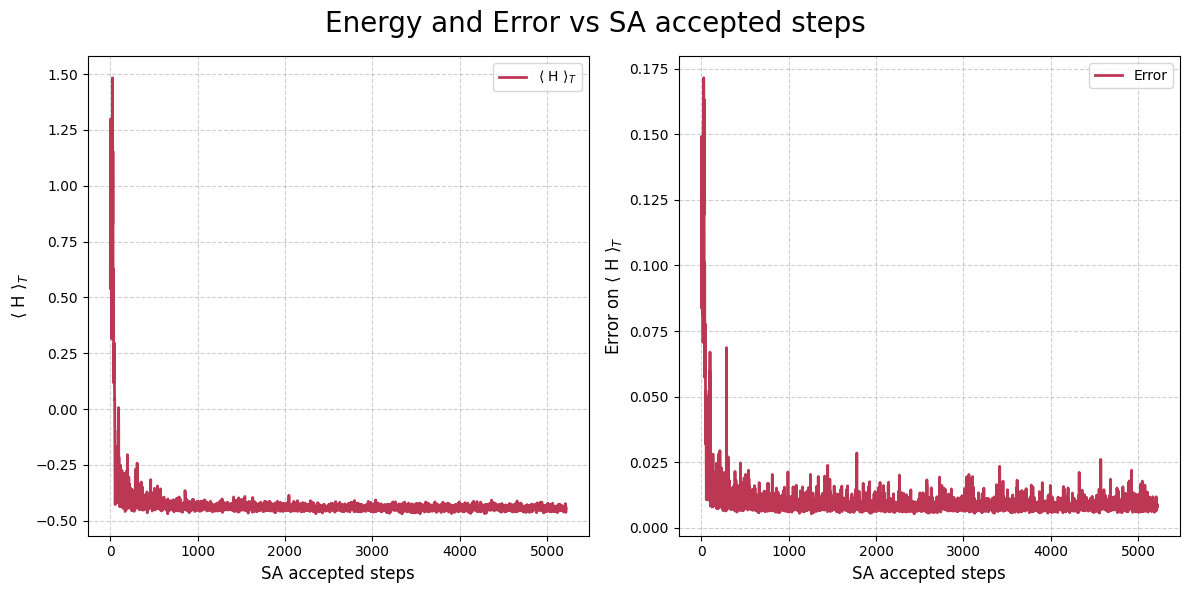

In [3]:

#x1, y1, error1 = np.loadtxt(file1, usecols=(0, 3, 4), delimiter='\t', unpack=True, skiprows=1)
x1, y1 = np.loadtxt("ex08.2/energy_vs_SA_steps.dat", usecols=(0, 3), delimiter='\t', unpack=True, skiprows=1)
x2, y2 = np.loadtxt("ex08.2/energy_vs_SA_steps.dat", usecols=(0, 4), delimiter='\t', unpack=True, skiprows=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))


axes[0].plot(x1, y1, color=color, label=rf'$\langle$ H $\rangle_T$')
#axes[0].fill_between(x1, y1 - error1, y1 + error1, 
#                     color=color, alpha=0.3, label='Error')
axes[0].set_ylabel(rf'$\langle$ H $\rangle_T$')
axes[0].set_xlabel('SA accepted steps')
#axes[0].tick_params(axis='x', labelbottom=False)
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].legend()


axes[1].plot(x2, y2, '-', color=color, label='Error')
axes[1].set_xlabel('SA accepted steps')
axes[1].set_ylabel(rf'Error on $\langle$ H $\rangle_T$')
axes[1].grid(True, linestyle='--', alpha=0.6)
axes[1].legend()

plt.suptitle('Energy and Error vs SA accepted steps', fontsize=20)
plt.tight_layout()
plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


Simulated annealing algorithm
Results
σ = 0.618567
μ = 0.803221


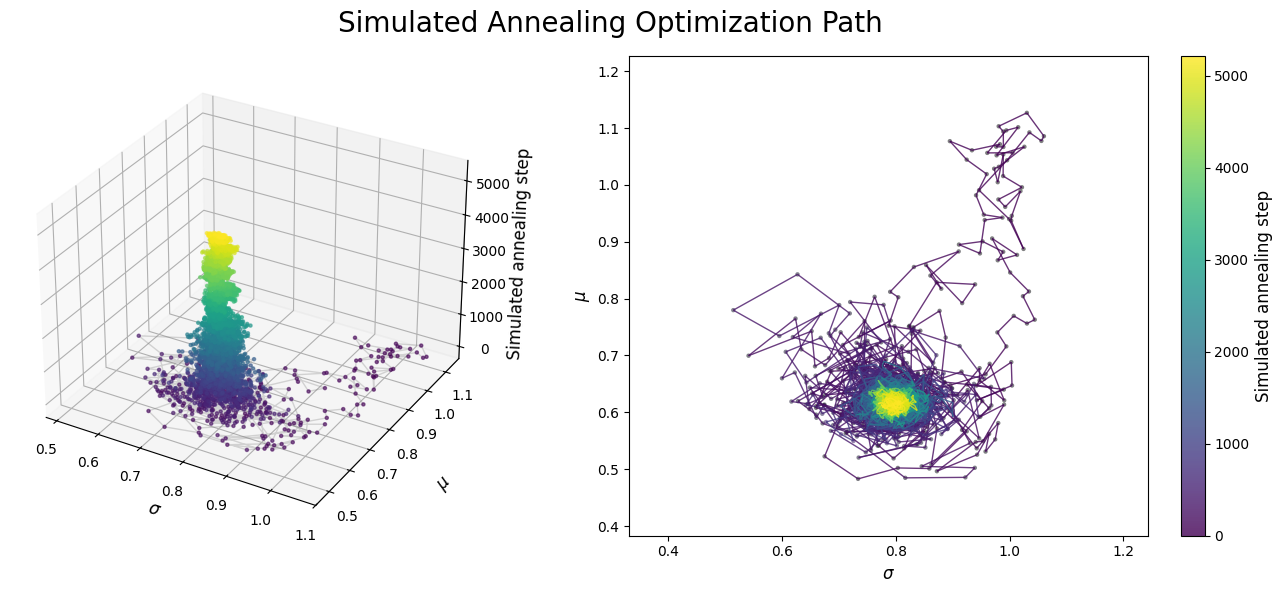

In [7]:
data = np.loadtxt("ex08.2/SimAnn.dat")
data_2 = np.loadtxt("ex08.2/SimAnn_accepted.dat", skiprows=1)

fig = plt.figure(figsize=(14, 6))
gs = fig.add_gridspec(1, 2)

ax3d = fig.add_subplot(gs[0, 0], projection='3d')
x = data_2[:, 1] # sigma
y = data_2[:, 2] # mu
z = np.arange(len(data_2))
colors = plt.cm.inferno(np.linspace(0, 1, len(data_2)))

ax3d.scatter(x, y, z, c=z, cmap='viridis', s=5, alpha=0.6)
ax3d.plot(x, y, z, color='gray', alpha=0.3, lw=1) 

ax3d.set_xlabel(r"$\sigma$")
ax3d.set_ylabel(r"$\mu$", labelpad=15) 
ax3d.set_zlabel("Simulated annealing step")

ax2 = fig.add_subplot(gs[0, 1])
points = np.array([x, y]).T.reshape(-1, 1, 2)
segments = np.concatenate([points[:-1], points[1:]], axis=1)

lc = LineCollection(segments, cmap='viridis', array=z, linewidths=1., alpha=0.8)
line = ax2.add_collection(lc)
ax2.scatter(x, y, c=z, cmap='inferno', s=10, edgecolor='none', alpha=0.5)

ax2.set_xlabel(r"$\sigma$")
ax2.set_ylabel(r"$\mu$")
ax2.axis('equal')
ax2.set_xlim(x.min() - 0.1, x.max() + 0.1)
ax2.set_ylim(y.min() - 0.1, y.max() + 0.1)

cbar = fig.colorbar(line, ax=ax2)
cbar.set_label("Simulated annealing step")

best_mu = data[-1, 1]
best_sigma = data[-1, 2]
print("===================================================================")
print("Simulated annealing algorithm")
print("===================================================================")
print("Results")
print(f"σ = {best_sigma}")
print(f"μ = {best_mu}")
print("===================================================================")

plt.suptitle('Simulated Annealing Optimization Path', fontsize=20)
plt.tight_layout()
plt.show()

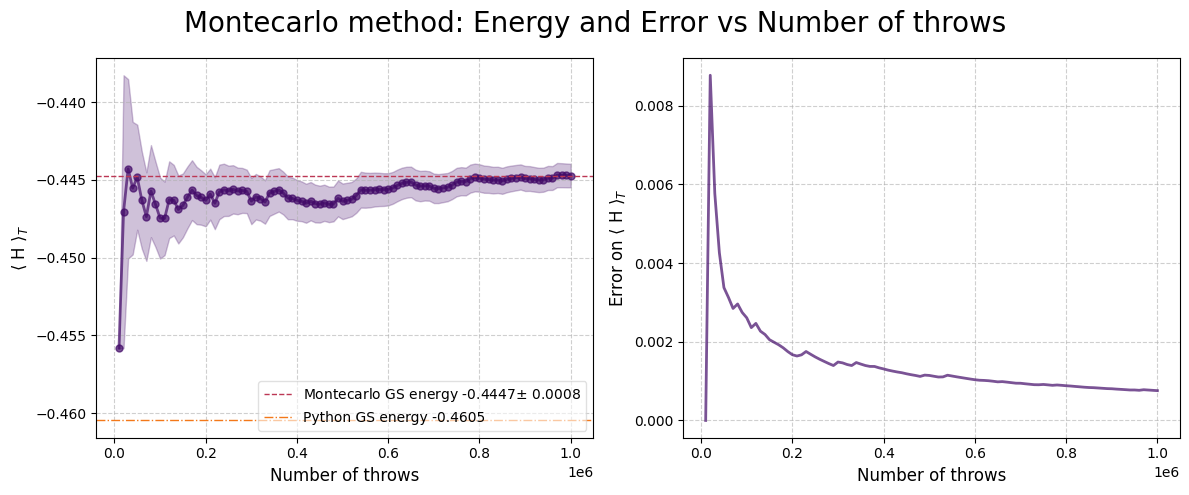

DIAGONALIZATION with PYTHON
Ground state energy:  -0.4604658796926825
1st excited state energy:  0.0974247133176052
2nd excited state energy:  1.9717331343931928
Montecarlo method
GS energy: -0.444717 ± 0.000757918


In [5]:
x = np.loadtxt("ex08.2/steps.dat", usecols=(0), delimiter='\t', unpack=True)
x1,y1,error1 = np.loadtxt("ex08.2/avg_energy.dat", usecols=(0, 1, 2), delimiter='\t', unpack=True)
fig, axs = plt.subplots(1,2,figsize=(12, 5))

axs[0].plot(x1, y1, 'o-', color=color2, alpha=0.7, markersize=5)
axs[0].fill_between(x1, y1-error1, y1+error1,
                       color=color2, alpha=0.25)
axs[0].axhline(y=y1[99], color=color, linestyle='--', lw=1, label=rf'Montecarlo GS energy {y1[99]:.4f}$\pm$ {error1[99]:.4f}')
axs[0].axhline(y=E[0], color=color3, linestyle='-.', lw=1, label=rf'Python GS energy {E[0]:.4f}')
axs[0].set_xlabel('Number of throws')
axs[0].set_ylabel(rf'$\langle$ H $\rangle_T$')
axs[0].legend(loc='lower right', frameon=True, fancybox=True,
                facecolor='white', framealpha=0.6)
axs[0].grid(True, linestyle='--', alpha=0.6)
axs[1].plot(x1, error1, '-', color=color2, alpha=0.7)
axs[1].set_xlabel('Number of throws')
axs[1].set_ylabel(rf'Error on $\langle$ H $\rangle_T$')
axs[1].grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Montecarlo method: Energy and Error vs Number of throws', fontsize=20)
plt.tight_layout()
plt.show()

print("===================================================================")
print("DIAGONALIZATION with PYTHON")
print("===================================================================")
print("Ground state energy: ", E[0])
print("1st excited state energy: ", E[1])
print("2nd excited state energy: ", E[2])
print("===================================================================")
print("Montecarlo method")
print("===================================================================")
print(f"GS energy: {y1[99]} \u00b1 {error1[99]}")
print("===================================================================")

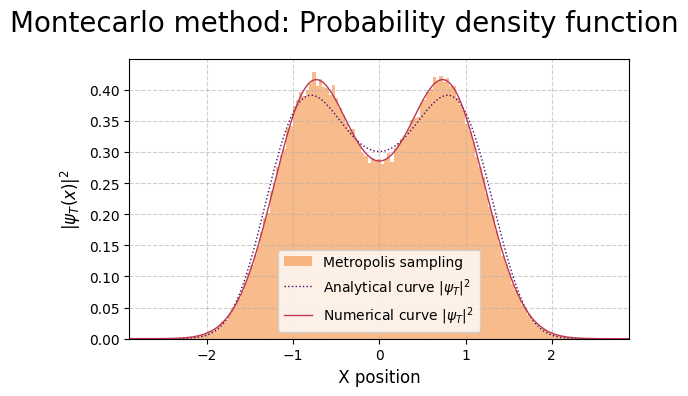

In [6]:
def psi_2(x, best_mu, best_sigma):
    return (np.exp(-(x-best_mu)**2/(2.0 * best_sigma**2)) + np.exp(-(x+best_mu)**2/(2.0 * best_sigma**2)))**2

x = np.loadtxt("ex08.2/steps.dat", usecols=(0), delimiter='\t', unpack=True)
x2 = np.linspace(-a/2, a/2, N)
x1,y1,error1 = np.loadtxt("ex08.2/avg_energy.dat", usecols=(0, 1, 2), delimiter='\t', unpack=True)
fig, axs = plt.subplots(figsize=(6, 4))

axs.hist(x,bins=150, color=color3, density=True, label = 'Metropolis sampling', alpha=0.5)
axs.plot(x2, psi[0]**2, color = color2, label=r'Analytical curve $|\psi_T|^2$ ', lw=1., linestyle=':')
axs.plot(x2, psi_2(x2, 0.803221, 0.618567)/(a*np.mean(psi_2(x2, 0.803221, 0.618567))), lw=1.,color = color, label=r'Numerical curve $|\psi_T|^2$ ')
axs.set_xlabel(' X position ')
axs.set_ylabel(rf'$|\psi_T(x)|^2$')
axs.set_xlim(-2.9,2.9)
axs.grid(True, linestyle='--', alpha=0.6)

plt.suptitle('Montecarlo method: Probability density function', fontsize=20)
plt.legend(loc='lower center', fontsize=10)
plt.tight_layout()
plt.show()

### Supplementary material

How can we describe a wave function as a vector? We set up a lattice of discrete points, spaced by a constant distance $dx$, and record the value of the function at each lattice point. In this way the wave function, $\Psi(x)$ become a vector:

$$
\Psi(x) \to \left[ \Psi(x_1), \Psi(x_2), ..., \Psi(x_N) \right] = 
\left[ \Psi_1, \Psi_2, ..., \Psi_N \right]
$$

The time independent Schrodinger equation 

$$
{\hat H} \Psi(x) = \left( -\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2} + V(x) \right) \Psi(x) = E \Psi(x)
$$

can be written in matrix form. But how do we write the second derivative at a particular point? Let's start with the first derivatives:
$$
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) \simeq \frac{\Psi_{i+1}-\Psi_{i}}{dx}\\
\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right) \simeq \frac{\Psi_{i}-\Psi_{i-1}}{dx}
$$

Thus, we can discretize the second derivative in the following way:
$$
\frac{\partial^2}{\partial x^2} \Psi(x=x_i) =
\frac{\frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i+1})/2\right) - \frac{\partial}{\partial x} \Psi\left(x=(x_i+x_{i-1})/2\right)}{dx} =
\frac{\Psi_{i+1}-2\Psi_{i}+\Psi_{i-1}}{dx^2}
$$

We finally obtain:

$$
\begin{bmatrix}
 \frac{\hbar^2}{m\,dx^2}+V(x_1)& -\frac{\hbar^2}{2m\,dx^2} & 0 & \dots  & 0 \\
-\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_2) & -\frac{\hbar^2}{2m\,dx^2} & \dots  & 0 \\
 0                        & -\frac{\hbar^2}{2m\,dx^2} & \frac{\hbar^2}{m\,dx^2}+V(x_3) & \dots  & 0 \\
 \vdots                   & \vdots                    & \vdots & \ddots & \vdots \\
 0                    & 0                & 0 & \dots  & \frac{\hbar^2}{m\,dx^2}+V(x_N)
\end{bmatrix}
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
= E
\begin{bmatrix}
\Psi_{1} \\
\Psi_{2} \\
\vdots \\
\Psi_{N}
\end{bmatrix}
$$

To solve the time independent Schrodinger equation we therefore have to find eigenstates and eigenvalues of the matrix just obtained.

Ground state energy:  -0.4604658796923901
1st excited state energy:  0.09742471331806084
2nd excited state energy:  1.9717331343935816


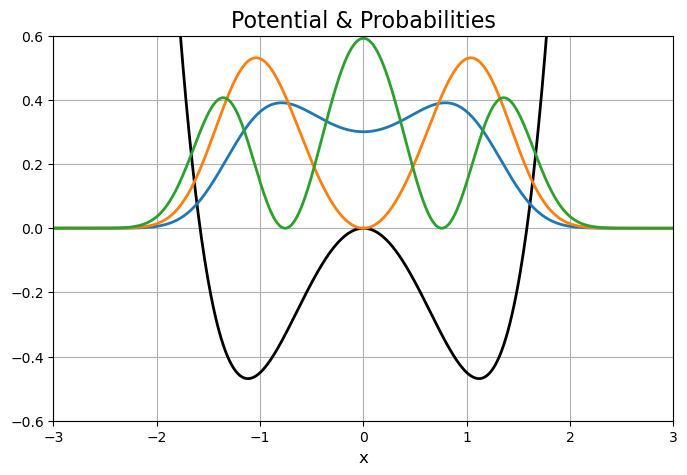

In [26]:
import numpy as np
import matplotlib.pyplot as plt

def Vpot(x):
    return (x**2 - 2.5)*x**2
    #return 0.5*x**2

hbar = 1
m = 1
a = 10
N = 1000 # number of iterations

# Step sizes
x = np.linspace(-a/2, a/2, N)
dx = x[1] - x[0] # the step size
V = Vpot(x)

# The central differences method: f" = (f_1 - 2*f_0 + f_-1)/dx^2

CDiff = np.diag(np.ones(N-1),-1)-2*np.diag(np.ones(N),0)+np.diag(np.ones(N-1),1)
# np.diag(np.array,k) construct a "diagonal" matrix using the np.array
# The default is k=0. Use k>0 for diagonals above the main diagonal, 
# and k<0 for diagonals below the main diagonal

# Hamiltonian matrix
H = (-(hbar**2)*CDiff)/(2*m*dx**2) + np.diag(V)

# Compute eigenvectors and their eigenvalues
E,psi = np.linalg.eigh(H)

# Take the transpose & normalize
psi = np.transpose(psi)
psi = psi/np.sqrt(dx)

print("Ground state energy: ", E[0])
print("1st excited state energy: ", E[1])
print("2nd excited state energy: ", E[2])

# Plot a few things
plt.figure(figsize=(8,5))
scale = 0.3
plt.plot(x, scale*V, color="Black", label="Potential") # plot the potential
plt.plot(x,(psi[0])**2)
plt.plot(x,(psi[1])**2)
plt.plot(x,(psi[2])**2)
plt.title("Potential & Probabilities")
plt.xlabel("x")
plt.grid(True)
plt.xlim((-3,3))
plt.ylim((-0.6,0.6))
plt.show()